# 04 — Pose Analysis

Per-pose MWI scores across participants: distributions, bilateral symmetry (Kneeling Knee Flexion & Standing Hip Abduction), and Spearman correlations between each pose and overall MWI.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CLEAN_PATH  = '../data/processed/MWI_clean.csv'
RAW_PATH    = '../data/raw/MWI_raw.csv'   
SURVEY_PATH = '../data/processed/combined_data.csv'

POSE_COLS = [
    'bilateral_leg_straddle',
    'kneeling_knee_flexion_left',
    'kneeling_knee_flexion_right',
    'prone_trunk_extension',
    'standing_hip_abduction_left',
    'standing_hip_abduction_right',
    'unilateral_hip_extension',
    'ssp',
]

POSE_SHORT = {
    'bilateral_leg_straddle':       'BLS',
    'kneeling_knee_flexion_left':   'KKF-L',
    'kneeling_knee_flexion_right':  'KKF-R',
    'prone_trunk_extension':        'PTE',
    'standing_hip_abduction_left':  'SHA-L',
    'standing_hip_abduction_right': 'SHA-R',
    'unilateral_hip_extension':     'UHE',
    'ssp':                          'SSP',
}

# Load from MWI_clean.csv
clean = pd.read_csv(CLEAN_PATH)
clean = clean.rename(columns={
    'bilateral_leg_straddle_mi4l':        'bilateral_leg_straddle',
    'kneeling_knee_flexion_left_mi4l':    'kneeling_knee_flexion_left',
    'kneeling_knee_flexion_right_mi4l':   'kneeling_knee_flexion_right',
    'prone_trunk_extension_mi4l':         'prone_trunk_extension',
    'standing_hip_abduction_left_mi4l':   'standing_hip_abduction_left',
    'standing_hip_abduction_right_mi4l':  'standing_hip_abduction_right',
    'unilateral_hip_extension_mi4l':      'unilateral_hip_extension',
    'shoulder_stick_pass_through_ssp':    'ssp',
})
wide = clean[['participant'] + POSE_COLS + ['n_poses', 'mwi']].copy()


raw = pd.read_csv(RAW_PATH)
raw.columns = raw.columns.str.strip()
raw['participant']    = raw['participant'].str.strip()
raw['movement_name']  = raw['movement_name'].str.strip()
raw['side']           = raw['side'].str.strip()
raw['mi4l']           = pd.to_numeric(raw['mi4l'], errors='coerce')

print(f'wide: {wide.shape[0]} participants × {len(POSE_COLS)} poses')
print(f'raw:  {raw.shape[0]} rows')


wide: 25 participants × 8 poses
raw:  227 rows


## 1. Per-person per-pose scores

Loaded from `MWI_clean.csv`.

In [ ]:
display = wide.set_index('participant')[POSE_COLS].rename(columns=POSE_SHORT)
display = display.sort_index()
print('Per-person per-pose scores:')
print(display.round(4).to_string())

Per-person per-pose scores:
                BLS   KKF-L   KKF-R     PTE   SHA-L   SHA-R     UHE     SSP
participant                                                                
P01          0.0690     NaN  0.0914  0.4622  0.5052  0.5198     NaN  0.6684
P02             NaN  0.1187  0.2211  0.4850  0.0579  0.2302     NaN  0.6928
P03          0.1774  0.0222  0.0931  0.2275  0.4173  0.3988  0.2366  0.5156
P04          0.1203  0.1072  0.1179  0.4247  0.4340  0.6786  0.2425  0.6604
P05          0.0352  0.0842  0.1632  0.4681  0.3492  0.4485  0.1990     NaN
P06          0.0000  0.0107  0.0005  0.2416  0.1330  0.2843     NaN  0.4884
P07             NaN  0.1495  0.1756  0.3853  0.4312  0.4765  0.2505  0.6417
P08          0.0340  0.1849  0.1982  0.2607  0.3612  0.4510     NaN  0.6502
P09             NaN  0.0359  0.0837  0.3804  0.1346  0.2759     NaN     NaN
P10          0.0389  0.0913  0.1268  0.3900  0.3358  0.0660  0.2324  0.6681
P11          0.2504  0.2638  0.1401  0.4964     NaN  0.4710 

## 3. Heatmap — per-person per-pose profile

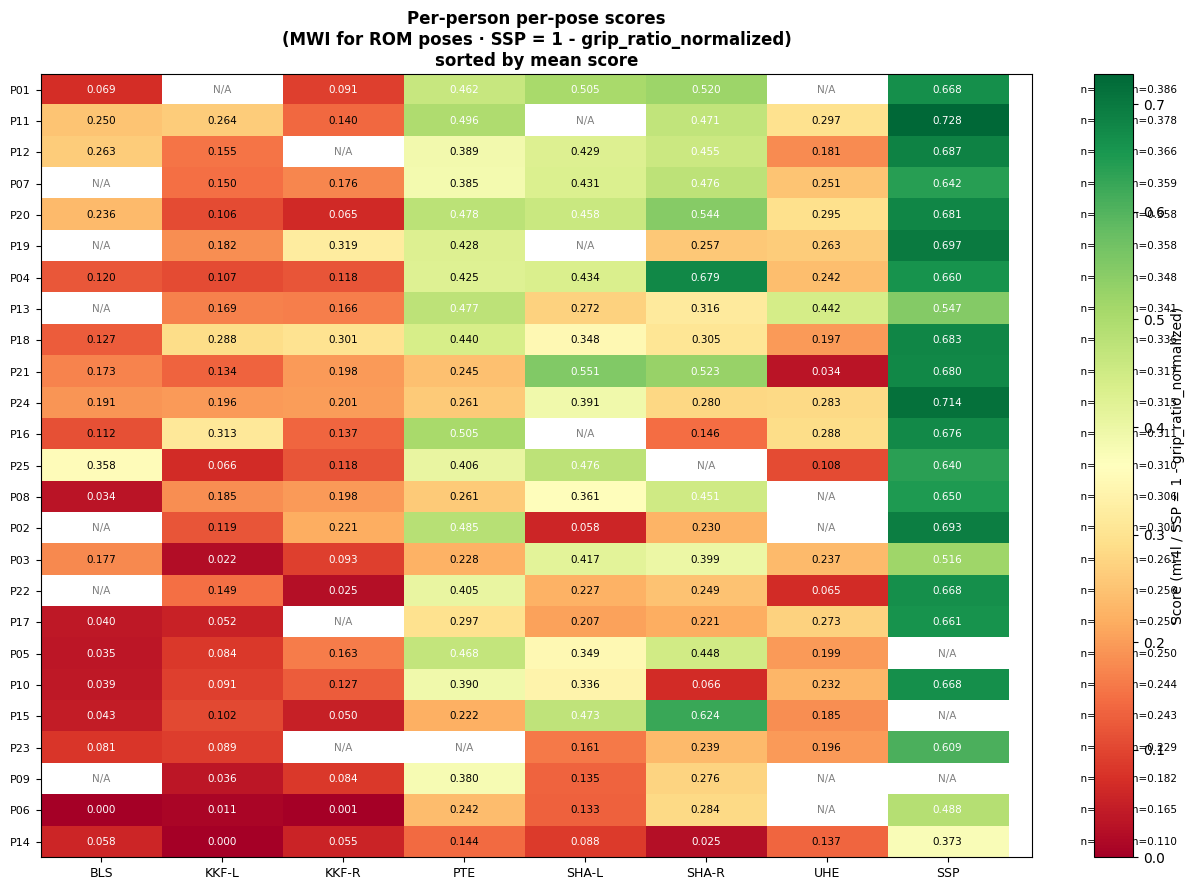

In [ ]:
# Sort participants by mean score
wide['mean_score'] = wide[POSE_COLS].mean(axis=1)
wide_sorted = wide.sort_values('mean_score', ascending=False).reset_index(drop=True)

matrix = wide_sorted.set_index('participant')[POSE_COLS].rename(columns=POSE_SHORT)

fig, ax = plt.subplots(figsize=(13, 9))
im = ax.imshow(matrix.values.astype(float), cmap='RdYlGn', aspect='auto',
               vmin=0, vmax=matrix.values[~np.isnan(matrix.values)].max())
plt.colorbar(im, ax=ax, label='Score (mi4l / SSP = 1 - grip_ratio_normalized)')

ax.set_xticks(range(len(matrix.columns)))
ax.set_xticklabels(matrix.columns, fontsize=9)
ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index, fontsize=8)

for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        val = matrix.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=7.5, color='black' if 0.1 < val < 0.45 else 'white')
        else:
            ax.text(j, i, 'N/A', ha='center', va='center', fontsize=7.5, color='grey')


for i, participant in enumerate(matrix.index):
    mean = wide_sorted.set_index('participant').loc[participant, 'mean_score']
    n    = wide_sorted.set_index('participant').loc[participant, POSE_COLS].notna().sum()
    ax.text(len(matrix.columns) + 0.05, i, f'  n={int(n)}  mean={mean:.3f}',
            va='center', fontsize=7.5)

ax.set_xlim(-0.5, len(matrix.columns) - 0.3)
ax.set_title(
    'Per-person per-pose scores\n(MWI for ROM poses · SSP = 1 - grip_ratio_normalized)\nsorted by mean score',
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.show()

## 4. Per-pose score distributions across participants

/var/folders/s_/c14ll07j3fvb_99plyhxh1m40000gn/T/ipykernel_48858/383707933.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(pose_vals, labels=pose_labels, patch_artist=True,


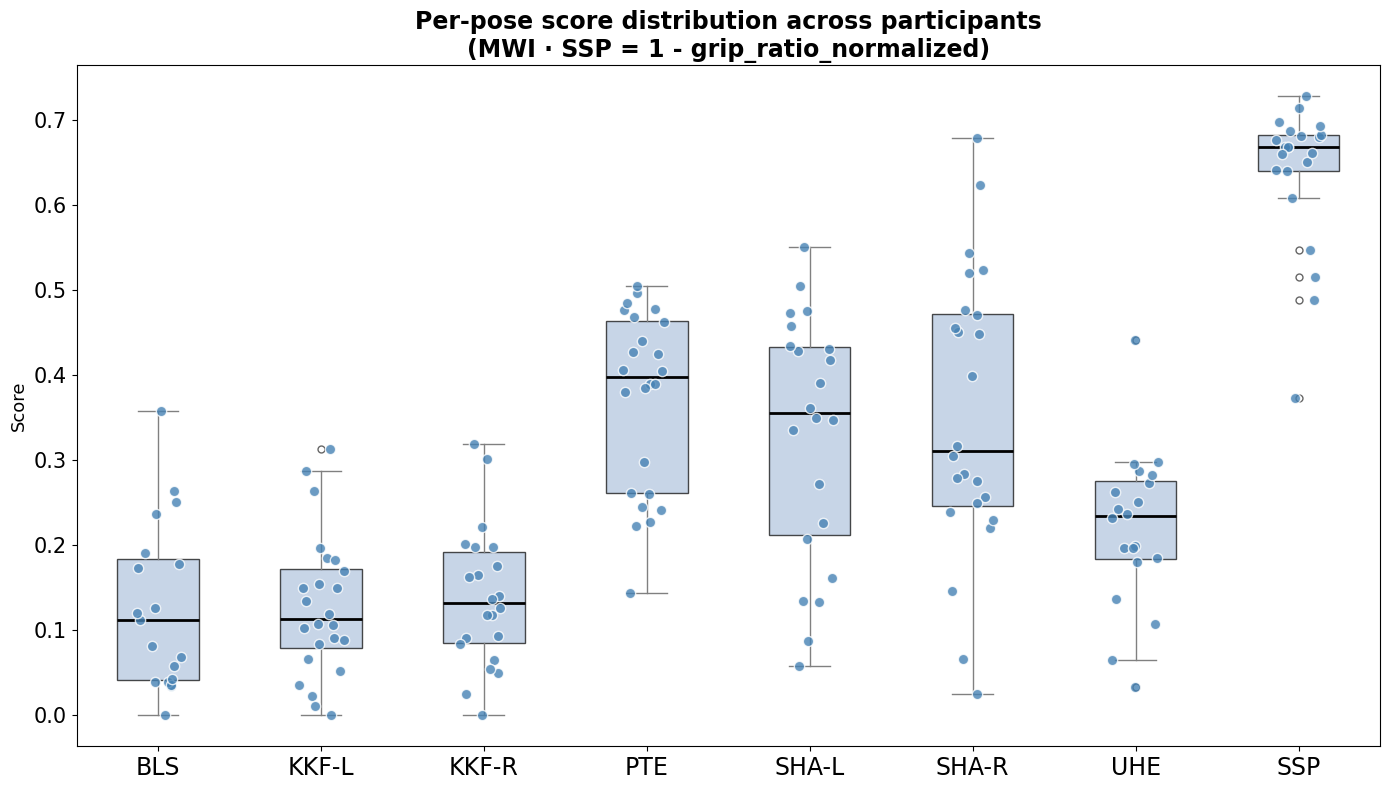

Per-pose summary:
 pose  n   mean    std    min    max
  BLS 19 0.1267 0.0957 0.0000 0.3581
KKF-L 24 0.1279 0.0812 0.0000 0.3127
KKF-R 22 0.1385 0.0798 0.0005 0.3193
  PTE 24 0.3716 0.1037 0.1438 0.5049
SHA-L 22 0.3291 0.1428 0.0579 0.5509
SHA-R 24 0.3535 0.1648 0.0247 0.6786
  UHE 20 0.2202 0.0890 0.0337 0.4419
  SSP 22 0.6378 0.0826 0.3734 0.7282


In [72]:
fig, ax = plt.subplots(figsize=(14, 8))

pose_vals   = [wide[p].dropna().values for p in POSE_COLS]
pose_labels = [POSE_SHORT[p] for p in POSE_COLS]

bp = ax.boxplot(pose_vals, labels=pose_labels, patch_artist=True,
                medianprops=dict(color='black', lw=2),
                boxprops=dict(facecolor='lightsteelblue', alpha=0.7),
                whiskerprops=dict(color='grey'),
                capprops=dict(color='grey'),
                flierprops=dict(marker='o', markersize=5, color='steelblue', alpha=0.6))

# Overlay individual points
rng = np.random.default_rng(42)
for i, (vals, label) in enumerate(zip(pose_vals, pose_labels), start=1):
    jitter = rng.uniform(-0.15, 0.15, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals,
               color='steelblue', s=55, zorder=5, alpha=0.8, edgecolor='white')

ax.set_ylabel('Score', fontsize=13)
ax.set_title('Per-pose score distribution across participants\n(MWI · SSP = 1 - grip_ratio_normalized)',
             fontweight='bold', fontsize=17)
ax.tick_params(axis='x', labelsize=17)
ax.tick_params(axis='y', labelsize=15)
plt.tight_layout()
plt.show()

# Summary stats per pose
summary = pd.DataFrame({
    'pose': pose_labels,
    'n':    [len(v) for v in pose_vals],
    'mean': [np.mean(v).round(4) for v in pose_vals],
    'std':  [np.std(v).round(4)  for v in pose_vals],
    'min':  [np.min(v).round(4)  for v in pose_vals],
    'max':  [np.max(v).round(4)  for v in pose_vals],
})
print('Per-pose summary:')
print(summary.to_string(index=False))


## 5. Per-pose score correlation with overall MWI

Spearman ρ between each individual pose score and `mwi` .


Participants with MWI: 25

Spearman ρ — pose score vs MWI:
 Pose   rho     p  n sig
KKF-L 0.711 0.000 24  **
SHA-L 0.650 0.001 22  **
  BLS 0.640 0.003 19  **
SHA-R 0.553 0.005 24  **
  SSP 0.539 0.010 22   *
  PTE 0.533 0.007 24  **
  UHE 0.445 0.049 20   *
KKF-R 0.439 0.041 22   *


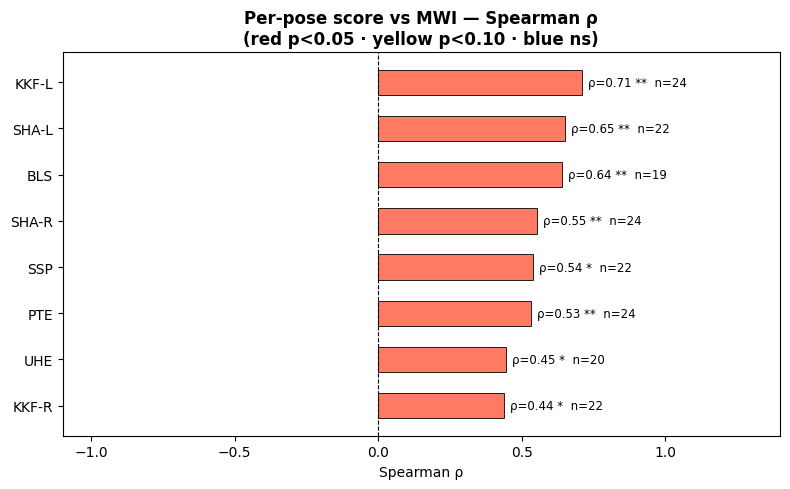

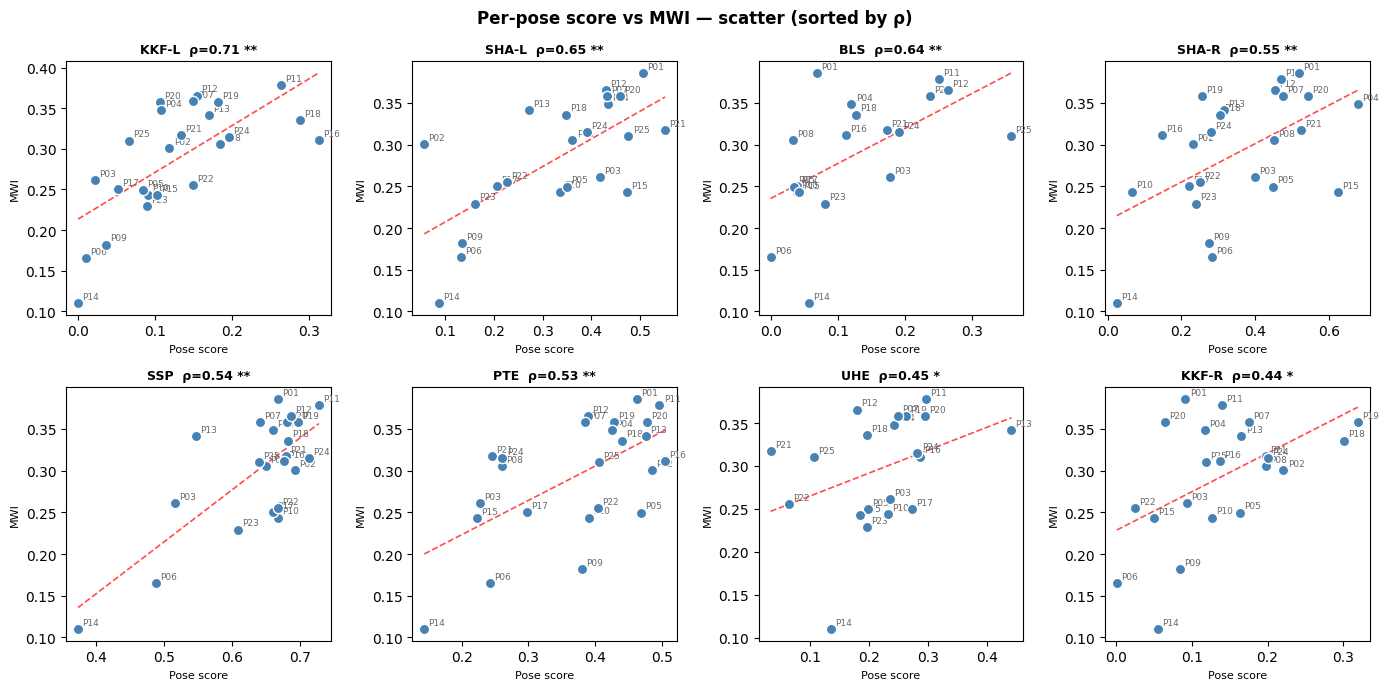

In [ ]:
from scipy import stats

merged = wide.dropna(subset=['mwi']).copy()
print(f'Participants with MWI: {len(merged)}')

# ── Compute Spearman ρ for each pose vs mwi ──────────────────────────────────
rows = []
for pose in POSE_COLS:
    sub = merged[[pose, 'mwi']].dropna()
    if len(sub) < 4:
        rows.append({'Pose': POSE_SHORT[pose], 'rho': float('nan'), 'p': float('nan'), 'n': len(sub)})
        continue
    r, p = stats.spearmanr(sub[pose].astype(float), sub['mwi'].astype(float))
    rows.append({'Pose': POSE_SHORT[pose], 'rho': round(r, 3), 'p': round(p, 3), 'n': len(sub)})

corr_df = pd.DataFrame(rows).sort_values('rho', ascending=False)
corr_df['sig'] = corr_df['p'].apply(lambda p: '**' if p < 0.01 else ('*' if p < 0.05 else ('.' if p < 0.10 else 'ns')))
print('\nSpearman ρ — pose score vs MWI:')
print(corr_df.to_string(index=False))

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sub_plot = corr_df.sort_values('rho', ascending=True)
colors = ['tomato' if p < 0.05 else ('gold' if p < 0.10 else 'steelblue') for p in sub_plot['p']]
bars = ax.barh(sub_plot['Pose'], sub_plot['rho'], color=colors, edgecolor='black',
               linewidth=0.7, alpha=0.85, height=0.55)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
for bar, (_, row) in zip(bars, sub_plot.iterrows()):
    x = bar.get_width()
    ax.text(x + (0.02 if x >= 0 else -0.02),
            bar.get_y() + bar.get_height() / 2,
            f"ρ={row['rho']:.2f} {row['sig']}  n={int(row['n'])}",
            va='center', ha='left' if x >= 0 else 'right', fontsize=8.5)
ax.set_xlabel('Spearman ρ')
ax.set_xlim(-1.1, 1.4)
ax.set_title('Per-pose score vs MWI — Spearman ρ\n(red p<0.05 · yellow p<0.10 · blue ns)',
             fontweight='bold')
plt.tight_layout()
plt.show()


short_to_col = {v: k for k, v in POSE_SHORT.items()}
pose_order = corr_df['Pose'].tolist()

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for ax, pose_short in zip(axes, pose_order):
    pose_col = short_to_col[pose_short]
    sub = merged[['participant', pose_col, 'mwi']].dropna()
    x, y = sub[pose_col].astype(float), sub['mwi'].astype(float)
    ax.scatter(x, y, color='steelblue', s=55, edgecolor='white', zorder=5)
    for _, row in sub.iterrows():
        ax.annotate(row['participant'], (row[pose_col], row['mwi']),
                    fontsize=6.5, color='dimgrey', xytext=(3, 3), textcoords='offset points')
    if len(x) > 2:
        m, b = np.polyfit(x, y, 1)
        xline = np.linspace(x.min(), x.max(), 50)
        ax.plot(xline, m * xline + b, 'r--', linewidth=1.2, alpha=0.7)
    r, p = stats.spearmanr(x, y)
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else ('.' if p < 0.10 else 'ns'))
    ax.set_title(f'{pose_short}  ρ={r:.2f} {sig}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Pose score', fontsize=8)
    ax.set_ylabel('MWI', fontsize=8)

for ax in axes[len(pose_order):]:
    ax.axis('off')

plt.suptitle('Per-pose score vs MWI — scatter (sorted by ρ)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


## 6. Bilateral symmetry of Kneeling Knee Flexion & Standing Hip Abduction



Kneeling Knee Flexion (n=21)
  Mean L = 0.1321,  Mean R = 0.1407
  Mean |asymmetry|            = 0.0592  (SD = 0.0488,  max = 0.1756)
  Asymmetry % of 0–1 scale    = 5.9%  (SD = 4.9%,  max = 17.6%)
  Asymmetry % of local mean   = 63.5%  (SD = 56.6%,  max = 200.0%)
  Left-dominant: 6,  Right-dominant: 13,  Symmetric: 2
  Wilcoxon L vs R: p = 0.2722

Standing Hip Abduction (n=21)
  Mean L = 0.3221,  Mean R = 0.3624
  Mean |asymmetry|            = 0.0911  (SD = 0.0742,  max = 0.2698)
  Asymmetry % of 0–1 scale    = 9.1%  (SD = 7.4%,  max = 27.0%)
  Asymmetry % of local mean   = 37.5%  (SD = 40.5%,  max = 134.3%)
  Left-dominant: 6,  Right-dominant: 15,  Symmetric: 0
  Wilcoxon L vs R: p = 0.0646


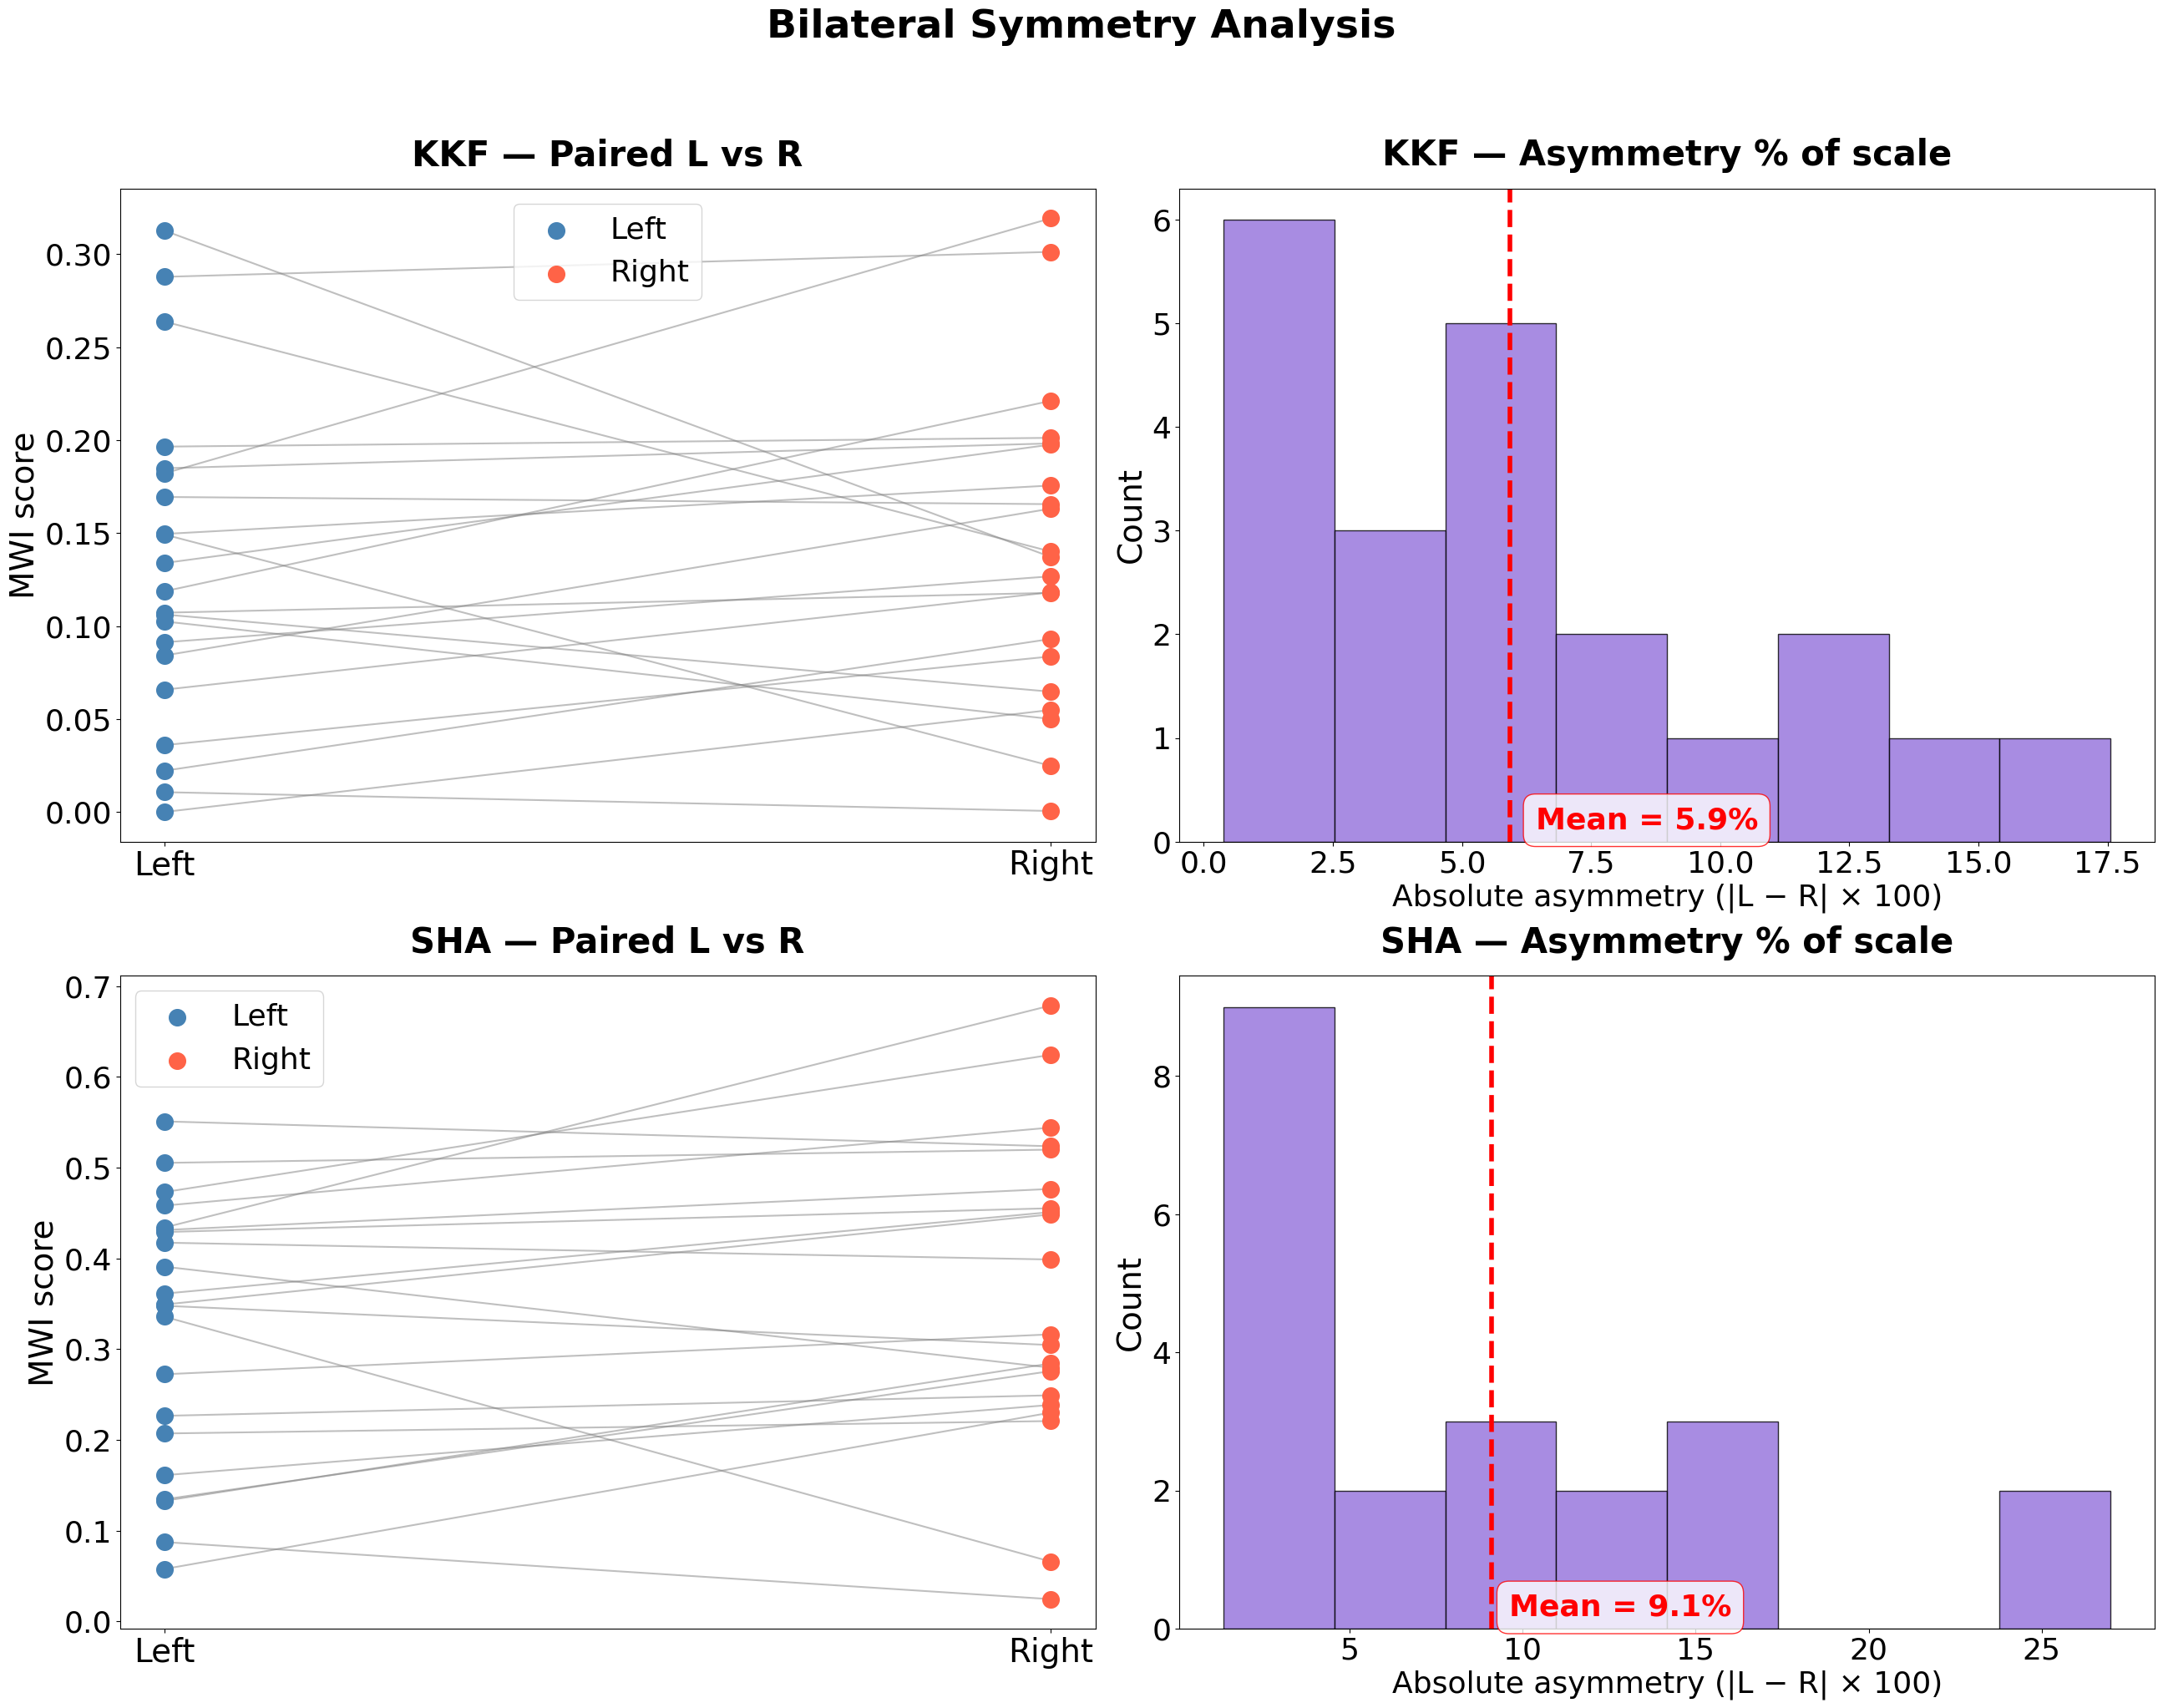

In [ ]:
from scipy.stats import wilcoxon

raw_sym = raw.copy()
raw_sym['mi4l_valid'] = raw_sym['mi4l_valid'].astype(str).str.lower() == 'true'
raw_sym = raw_sym[raw_sym['mi4l_valid'] & (raw_sym['mi4l'] <= 1.5)]

def bilateral_symmetry(df, pose):
    sub   = df[df['movement_name'] == pose]
    left  = sub[sub['side'] == 'left'].set_index('participant')['mi4l']
    right = sub[sub['side'] == 'right'].set_index('participant')['mi4l']
    common = left.index.intersection(right.index)

    diff       = left[common] - right[common]
    asym       = diff.abs()
    asym_rel   = asym / ((left[common] + right[common]) / 2) * 100  # % of local mean
    asym_scale = asym * 100                                          # % of 0–1 scale

    stat, p_wilcox = wilcoxon(left[common], right[common])

    print(f'\n{pose} (n={len(common)})')
    print(f'  Mean L = {left[common].mean():.4f},  Mean R = {right[common].mean():.4f}')
    print(f'  Mean |asymmetry|            = {asym.mean():.4f}  (SD = {asym.std():.4f},  max = {asym.max():.4f})')
    print(f'  Asymmetry % of 0–1 scale    = {asym_scale.mean():.1f}%  (SD = {asym_scale.std():.1f}%,  max = {asym_scale.max():.1f}%)')
    print(f'  Asymmetry % of local mean   = {asym_rel.mean():.1f}%  (SD = {asym_rel.std():.1f}%,  max = {asym_rel.max():.1f}%)')
    print(f'  Left-dominant: {(diff > 0.01).sum()},  '
          f'Right-dominant: {(diff < -0.01).sum()},  '
          f'Symmetric: {(diff.abs() <= 0.01).sum()}')
    print(f'  Wilcoxon L vs R: p = {p_wilcox:.4f}')

    return asym, asym_scale, left[common], right[common]

asym_results = {}
for pose in ['Kneeling Knee Flexion', 'Standing Hip Abduction']:
    asym, asym_scale, L, R = bilateral_symmetry(raw_sym, pose)
    asym_results[pose] = {'asym': asym, 'asym_scale': asym_scale, 'left': L, 'right': R}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(26, 20))

for row_idx, pose in enumerate(['Kneeling Knee Flexion', 'Standing Hip Abduction']):
    L          = asym_results[pose]['left']
    R          = asym_results[pose]['right']
    asym       = asym_results[pose]['asym']
    asym_scale = asym_results[pose]['asym_scale']
    short      = 'KKF' if 'Knee' in pose else 'SHA'

    # Paired dot plot
    ax = axes[row_idx, 0]
    for p in L.index:
        ax.plot([0, 1], [L[p], R[p]], color='grey', alpha=0.5, linewidth=1.5)
    ax.scatter([0] * len(L), L.values, color='steelblue', s=200, zorder=5, label='Left')
    ax.scatter([1] * len(R), R.values, color='tomato',   s=200, zorder=5, label='Right')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Left', 'Right'], fontsize=28)
    ax.set_ylabel('MWI score', fontsize=28)
    ax.tick_params(axis='y', labelsize=26)
    ax.set_title(f'{short} — Paired L vs R', fontweight='bold', fontsize=30, pad=20)
    ax.legend(fontsize=26)

    # Asymmetry % of scale distribution
    ax = axes[row_idx, 1]
    ax.hist(asym_scale.values, bins=8, color='mediumpurple', edgecolor='black', alpha=0.8)
    mean_val = asym_scale.mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=4.0)
    ax.text(mean_val + 0.5, ax.get_ylim()[1] * 0.02,
            f'Mean = {mean_val:.1f}%',
            color='red', fontsize=26, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='red', alpha=0.8))
    ax.set_xlabel('Absolute asymmetry (|L − R| × 100)', fontsize=26)
    ax.set_ylabel('Count', fontsize=28)
    ax.tick_params(axis='both', labelsize=26)
    ax.set_title(f'{short} — Asymmetry % of scale', fontweight='bold', fontsize=30, pad=20)

plt.suptitle('Bilateral Symmetry Analysis', fontweight='bold', fontsize=34, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
